Apply NLP techniques to identify whether a message is SPAM or not

https://www.kaggle.com/datasets/team-ai/spam-text-message-classification

In [1]:
import os
import zipfile
from pathlib import Path
from kaggle.api.kaggle_api_extended import KaggleApi

# -------------------------------
# Configuration
# -------------------------------
DATASET = "team-ai/spam-text-message-classification"      
DOWNLOAD_DIR = Path("data")

# -------------------------------
# Create data directory
# -------------------------------
DOWNLOAD_DIR.mkdir(exist_ok=True)

# -------------------------------
# Authenticate Kaggle
# -------------------------------
api = KaggleApi()
api.authenticate()

# -------------------------------
# Download Dataset
# -------------------------------
print("Downloading dataset...")

api.dataset_download_files(
    DATASET,
    path=str(DOWNLOAD_DIR),
    unzip=False
)

print("Download completed.")

# -------------------------------
# Extract ZIP
# -------------------------------
zip_files = list(DOWNLOAD_DIR.glob("*.zip"))

if zip_files:
    print("Extracting dataset...")

    with zipfile.ZipFile(zip_files[0], "r") as zip_ref:
        zip_ref.extractall(DOWNLOAD_DIR)

    print("Extraction completed.")
else:
    print("No ZIP file found.")

print(f"Dataset available at: {DOWNLOAD_DIR.resolve()}")

Dataset URL: https://www.kaggle.com/datasets/team-ai/spam-text-message-classification
Download completed.
Extracting dataset...
Extraction completed.
Dataset available at: C:\Users\richi\DATA SCIENCE - IIT GUWAHATI\DEPLOYMENT\Spam_Detection\data


In [ ]:
# !mkdir -p ~/.kaggle
# !cp kaggle.json ~/.kaggle/

In [ ]:
# !kaggle datasets download -d team-ai/spam-text-message-classification

In [ ]:
# import zipfile
# zip_ref = zipfile.ZipFile('/content/spam-text-message-classification.zip', 'r')
# zip_ref.extractall('/content')
# zip_ref.close()

In [4]:

# !pip install lightgbm catboost xgboost
# !pip install emoji contractions textblob
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import classification_report
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,BatchNormalization,Dropout
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import emoji
import contractions
from textblob import TextBlob
import re
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\richi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\richi\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [8]:
# Load the data
# C:\Users\richi\DATA SCIENCE - IIT GUWAHATI\DEPLOYMENT\Spam_Detection\data\SPAM text message 20170820 - Data.csv
Spam_dataset = pd.read_csv('C:\\Users\\richi\\DATA SCIENCE - IIT GUWAHATI\\DEPLOYMENT\\Spam_Detection\\data\\SPAM text message 20170820 - Data.csv')

In [9]:
def clean_text(text):
    # Initialize Lemmatizer
    lemmatizer = WordNetLemmatizer()

    # 1. Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # 2. Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # 3. Expand contractions (e.g., don't -> do not)
    text = contractions.fix(text)

    # 4. Convert emojis to text
    text = emoji.demojize(text, delimiters=(" ", " "))

    # 5. Convert to lowercase
    text = text.lower()

    # 6. Remove numbers
    text = re.sub(r'\d+', '', text)

    # 7. Remove special characters but keep letters and spaces
    text = re.sub(r'[^a-z\s]', ' ', text)

    # 8. Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # 9. Spell correction (Note: can be slow)
    text = str(TextBlob(text).correct())

    # 10. Tokenize and Lemmatize
    words = text.split()
    cleaned_words = [lemmatizer.lemmatize(w) for w in words]

    return " ".join(cleaned_words)

# Apply the updated cleaning function
Spam_dataset['Cleaned_Message'] = Spam_dataset['Message'].apply(clean_text)

# Preview the results
Spam_dataset.head()

,Category,Message,Cleaned_Message
0,ham,"Go until jurong point, crazy.. Available only ...",go until during point crazy available only in ...
1,ham,Ok lar... Joking wif u oni...,ok war joking if you on
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wily come to win a cup final t...
3,ham,U dun say so early hor... U c already then say...,you dun say so early for you c already then say
4,ham,"Nah I don't think he goes to usf, he lives aro...",ah i do not think he go to u he life around he...


C:\Users\richi\AppData\Local\Temp\ipykernel_14256\960820361.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=Spam_dataset, x='Category', palette='viridis')


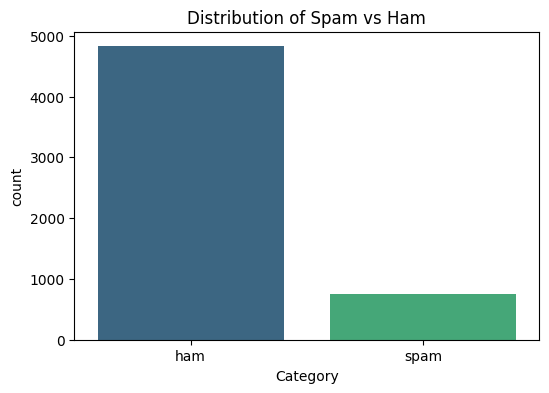

--- Class Distribution Statistics ---
Category
ham     4825
spam     747
Name: count, dtype: int64
Category
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64

--- Message Length Statistics by Category ---
           count       mean        std  min    25%    50%    75%    max
Category                                                               
ham       4825.0   71.44829  58.434864  2.0   33.0   52.0   93.0  910.0
spam       747.0  137.98929  29.980287  7.0  132.0  149.0  157.0  223.0


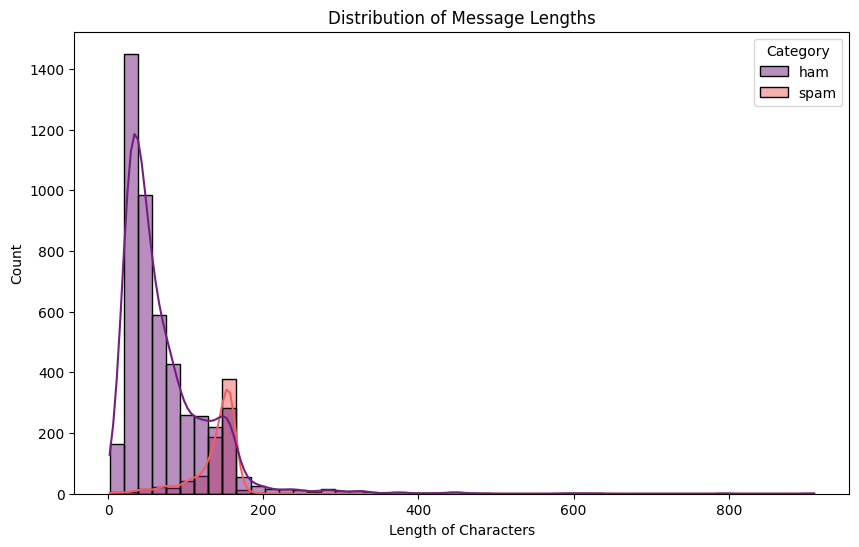


--- Generating Word Clouds ---


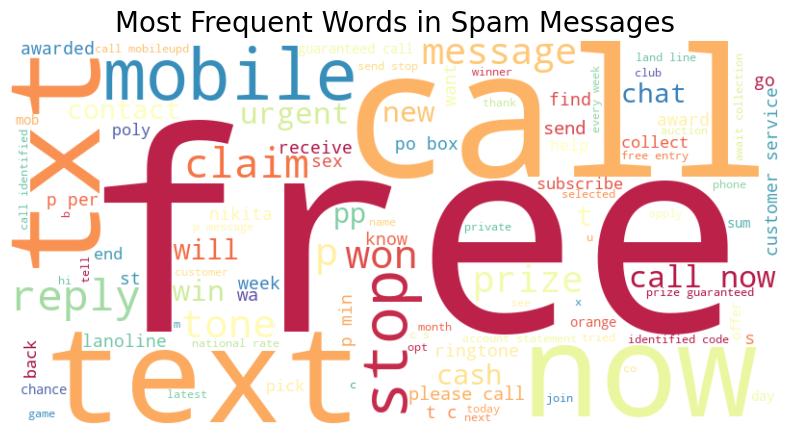

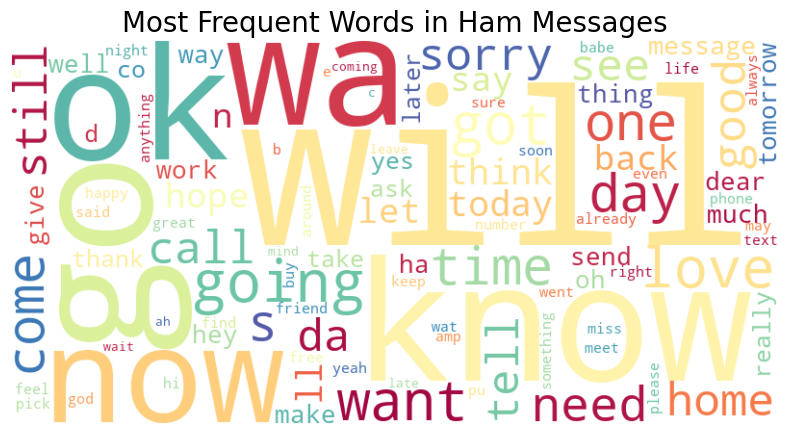

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# 1. Basic Statistical Analysis: Class Distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=Spam_dataset, x='Category', palette='viridis')
plt.title('Distribution of Spam vs Ham')
plt.show()

print("--- Class Distribution Statistics ---")
print(Spam_dataset['Category'].value_counts())
print(Spam_dataset['Category'].value_counts(normalize=True) * 100)

# 2. Statistical Analysis of Message Lengths
Spam_dataset['Message_Length'] = Spam_dataset['Message'].apply(len)

print("\n--- Message Length Statistics by Category ---")
print(Spam_dataset.groupby('Category')['Message_Length'].describe())

plt.figure(figsize=(10, 6))
sns.histplot(data=Spam_dataset, x='Message_Length', hue='Category', kde=True, bins=50, palette='magma')
plt.title('Distribution of Message Lengths')
plt.xlabel('Length of Characters')
plt.show()

# 3. Word Cloud Generation
def generate_wordcloud(text, title):
    wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='Spectral', max_words=100).generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=20)
    plt.show()

print("\n--- Generating Word Clouds ---")
spam_text = " ".join(Spam_dataset[Spam_dataset['Category'] == 'spam']['Cleaned_Message'])
ham_text = " ".join(Spam_dataset[Spam_dataset['Category'] == 'ham']['Cleaned_Message'])

generate_wordcloud(spam_text, 'Most Frequent Words in Spam Messages')
generate_wordcloud(ham_text, 'Most Frequent Words in Ham Messages')

In [11]:
# Define features and target
X = Spam_dataset['Cleaned_Message']
y = Spam_dataset['Category']

# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Training set size: 4457
Test set size: 1115


In [12]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
import pandas as pd
from sklearn.metrics import confusion_matrix, roc_auc_score

In [13]:
# Encode the target labels (ham -> 0, spam -> 1)
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

In [14]:
# Define Vectorizers
vectorizers = {
    'TF-IDF (Unigram)': TfidfVectorizer(max_features=5000),
    'TF-IDF (Bi-gram)': TfidfVectorizer(max_features=5000, ngram_range=(1, 2)),
    'CountVectorizer (Unigram)': CountVectorizer(max_features=5000),
    'CountVectorizer (Bi-gram)': CountVectorizer(max_features=5000, ngram_range=(1, 2))
}

def compare_vectorization_methods(models, vectorizers, X_train, y_train, X_test, y_test):
    all_results = []

    for vec_name, vec in vectorizers.items():
        print(f"Processing with {vec_name}...")
        # Transform data
        X_train_vec = vec.fit_transform(X_train).toarray()
        X_test_vec = vec.transform(X_test).toarray()

        for model_name, model in models.items():
            # Clone the model to ensure a fresh start for each vectorizer
            from sklearn.base import clone
            m = clone(model)

            m.fit(X_train_vec, y_train)
            preds = m.predict(X_test_vec)

            # Probability estimates for ROC AUC if available
            try:
                probs = m.predict_proba(X_test_vec)[:, 1]
            except:
                # For models like SVC without probability=True, use decision function if available
                try:
                    probs = m.decision_function(X_test_vec)
                except:
                    probs = preds

            all_results.append({
                'Vectorizer': vec_name,
                'Model': model_name,
                'Test Accuracy': accuracy_score(y_test, preds),
                'Test F1': f1_score(y_test, preds),
                'Test Precision': precision_score(y_test, preds),
                'Test Recall': recall_score(y_test, preds),
                'ROC AUC': roc_auc_score(y_test, probs),
                'Confusion Matrix': confusion_matrix(y_test, preds).tolist()
            })

    return pd.DataFrame(all_results)

# Define base models
base_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators=100),
    'SVM': SVC(probability=True),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    'LGBM': LGBMClassifier(verbose=-1),
    'CatBoost': CatBoostClassifier(verbose=0)
}



In [15]:
# Run the comparison
comparison_df = compare_vectorization_methods(base_models, vectorizers, X_train, y_train_encoded, X_test, y_test_encoded)


Processing with TF-IDF (Unigram)...


c:\Users\richi\DATA SCIENCE - IIT GUWAHATI\DEPLOYMENT\Spam_Detection\myenv\lib\site-packages\xgboost\training.py:200: UserWarning: [14:46:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\richi\DATA SCIENCE - IIT GUWAHATI\DEPLOYMENT\Spam_Detection\myenv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\richi\DATA SCIENCE - IIT GUWAHATI\DEPLOYMENT\Spam_Detection\myenv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Processing with TF-IDF (Bi-gram)...


c:\Users\richi\DATA SCIENCE - IIT GUWAHATI\DEPLOYMENT\Spam_Detection\myenv\lib\site-packages\xgboost\training.py:200: UserWarning: [14:50:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\richi\DATA SCIENCE - IIT GUWAHATI\DEPLOYMENT\Spam_Detection\myenv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\richi\DATA SCIENCE - IIT GUWAHATI\DEPLOYMENT\Spam_Detection\myenv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Processing with CountVectorizer (Unigram)...


c:\Users\richi\DATA SCIENCE - IIT GUWAHATI\DEPLOYMENT\Spam_Detection\myenv\lib\site-packages\xgboost\training.py:200: UserWarning: [14:53:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\richi\DATA SCIENCE - IIT GUWAHATI\DEPLOYMENT\Spam_Detection\myenv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\richi\DATA SCIENCE - IIT GUWAHATI\DEPLOYMENT\Spam_Detection\myenv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Processing with CountVectorizer (Bi-gram)...


c:\Users\richi\DATA SCIENCE - IIT GUWAHATI\DEPLOYMENT\Spam_Detection\myenv\lib\site-packages\xgboost\training.py:200: UserWarning: [14:56:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\richi\DATA SCIENCE - IIT GUWAHATI\DEPLOYMENT\Spam_Detection\myenv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\richi\DATA SCIENCE - IIT GUWAHATI\DEPLOYMENT\Spam_Detection\myenv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [16]:
# Display comparison table
print("\n--- Feature Engineering & Model Comparison Table ---")
comparison_df_sorted = comparison_df.sort_values(by='Test F1', ascending=False)
import IPython
IPython.display.display(comparison_df_sorted)


--- Feature Engineering & Model Comparison Table ---


,Vectorizer,Model,Test Accuracy,Test F1,Test Precision,Test Recall,ROC AUC,Confusion Matrix
5,TF-IDF (Unigram),LGBM,0.984753,0.940351,0.985294,0.899329,0.985785,"[[964, 2], [15, 134]]"
3,TF-IDF (Unigram),SVM,0.983857,0.936170,0.992481,0.885906,0.989558,"[[965, 1], [17, 132]]"
14,CountVectorizer (Unigram),Logistic Regression,0.983857,0.935714,1.000000,0.879195,0.986063,"[[966, 0], [18, 131]]"
10,TF-IDF (Bi-gram),SVM,0.982960,0.932384,0.992424,0.879195,0.989912,"[[965, 1], [18, 131]]"
21,CountVectorizer (Bi-gram),Logistic Regression,0.982063,0.929078,0.984962,0.879195,0.985403,"[[964, 2], [18, 131]]"
17,CountVectorizer (Unigram),SVM,0.982063,0.928058,1.000000,0.865772,0.982193,"[[966, 0], [20, 129]]"
25,CountVectorizer (Bi-gram),XGBoost,0.981166,0.926829,0.963768,0.892617,0.988133,"[[961, 5], [16, 133]]"
19,CountVectorizer (Unigram),LGBM,0.980269,0.922535,0.970370,0.879195,0.988800,"[[962, 4], [18, 131]]"
12,TF-IDF (Bi-gram),LGBM,0.980269,0.922535,0.970370,0.879195,0.987216,"[[962, 4], [18, 131]]"
18,CountVectorizer (Unigram),XGBoost,0.980269,0.922535,0.970370,0.879195,0.984472,"[[962, 4], [18, 131]]"


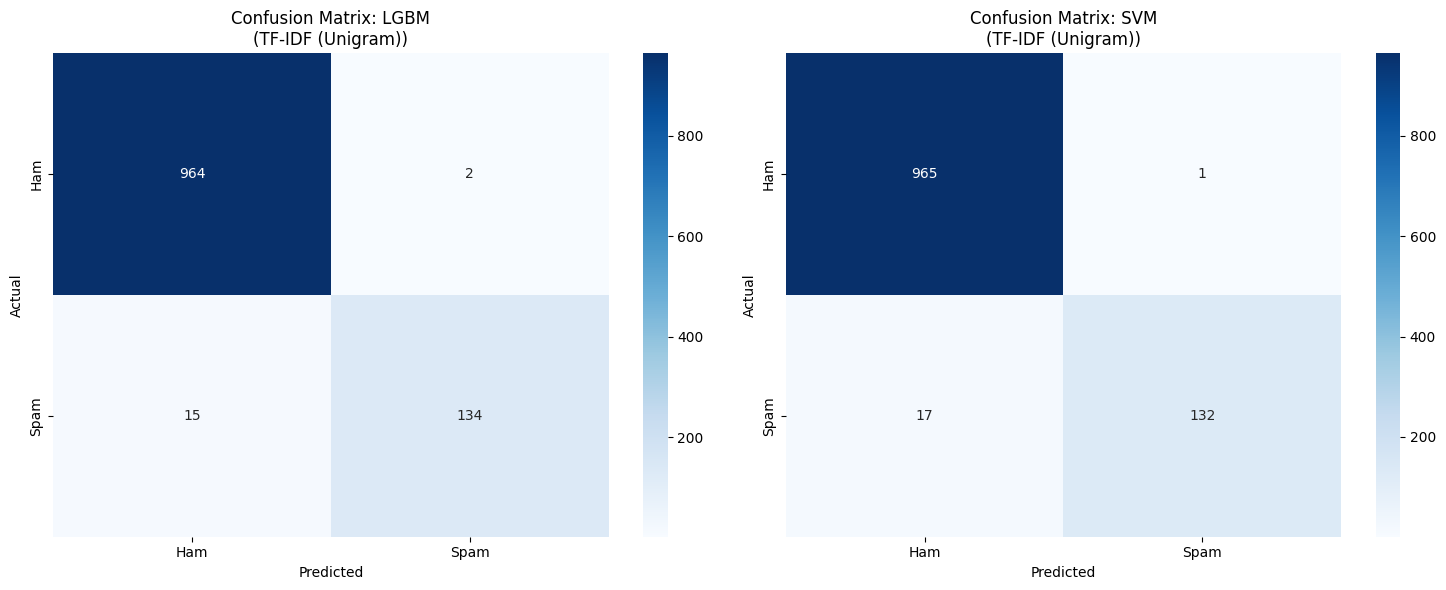


DETAILED PERFORMANCE: LGBM using TF-IDF (Unigram)
ROC AUC Score: 0.9858
Test Accuracy: 0.9848
Test F1 Score: 0.9404

Classification Logic Summary:
True Negatives (Ham): 964
False Positives (Spam): 2
False Negatives (Ham): 15
True Positives (Spam): 134

DETAILED PERFORMANCE: SVM using TF-IDF (Unigram)
ROC AUC Score: 0.9896
Test Accuracy: 0.9839
Test F1 Score: 0.9362

Classification Logic Summary:
True Negatives (Ham): 965
False Positives (Spam): 1
False Negatives (Ham): 17
True Positives (Spam): 132


In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report

# 1. Identify Top 2 Models from the comparison results
top_2_results = comparison_df.sort_values(by='Test F1', ascending=False).head(2)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for i, (index, row) in enumerate(top_2_results.iterrows()):
    model_name = row['Model']
    vec_name = row['Vectorizer']
    cm = np.array(row['Confusion Matrix'])

    # Plot Confusion Matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
    axes[i].set_title(f"Confusion Matrix: {model_name}\n({vec_name})")
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# 2. Display detailed Accuracy Metrics (Classification Report)
for index, row in top_2_results.iterrows():
    print(f"\n{'='*60}")
    print(f"DETAILED PERFORMANCE: {row['Model']} using {row['Vectorizer']}")
    print(f"{'='*60}")
    print(f"ROC AUC Score: {row['ROC AUC']:.4f}")
    print(f"Test Accuracy: {row['Test Accuracy']:.4f}")
    print(f"Test F1 Score: {row['Test F1']:.4f}")
    print("\nClassification Logic Summary:")
    # Note: Since we stored the results, we can calculate precision/recall per class if needed,
    # but the primary metrics are already in the comparison_df.
    print(f"True Negatives (Ham): {row['Confusion Matrix'][0][0]}")
    print(f"False Positives (Spam): {row['Confusion Matrix'][0][1]}")
    print(f"False Negatives (Ham): {row['Confusion Matrix'][1][0]}")
    print(f"True Positives (Spam): {row['Confusion Matrix'][1][1]}")

In [18]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

# 1. Dynamically identify the top 2 models and their corresponding vectorizers
top_2_info = comparison_df.sort_values(by='Test F1', ascending=False).head(2)

print("--- Stratified Cross-Validation on Top 2 Models ---\n")

for index, row in top_2_info.iterrows():
    model_name = row['Model']
    vec_name = row['Vectorizer']

    # Re-initialize the specific model and vectorizer
    model = base_models[model_name]
    vectorizer = vectorizers[vec_name]

    # Vectorize the entire cleaned dataset for CV
    X_all_vec = vectorizer.fit_transform(X).toarray()
    y_all_encoded = le.fit_transform(y)

    # Define Stratified K-Fold
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Calculate Cross-Validation Scores
    cv_f1_scores = cross_val_score(model, X_all_vec, y_all_encoded, cv=skf, scoring='f1')
    cv_accuracy_scores = cross_val_score(model, X_all_vec, y_all_encoded, cv=skf, scoring='accuracy')

    print(f"Model: {model_name}")
    print(f"Vectorizer: {vec_name}")
    print(f"Mean CV F1 Score: {np.mean(cv_f1_scores):.4f} (+/- {np.std(cv_f1_scores):.4f})")
    print(f"Mean CV Accuracy: {np.mean(cv_accuracy_scores):.4f} (+/- {np.std(cv_accuracy_scores):.4f})")
    print("-" * 40)

--- Stratified Cross-Validation on Top 2 Models ---



c:\Users\richi\DATA SCIENCE - IIT GUWAHATI\DEPLOYMENT\Spam_Detection\myenv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\richi\DATA SCIENCE - IIT GUWAHATI\DEPLOYMENT\Spam_Detection\myenv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\richi\DATA SCIENCE - IIT GUWAHATI\DEPLOYMENT\Spam_Detection\myenv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\richi\DATA SCIENCE - IIT GUWAHATI\DEPLOYMENT\Spam_Detection\myenv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\richi\DATA SCIENCE 

Model: LGBM
Vectorizer: TF-IDF (Unigram)
Mean CV F1 Score: 0.9232 (+/- 0.0149)
Mean CV Accuracy: 0.9804 (+/- 0.0035)
----------------------------------------
Model: SVM
Vectorizer: TF-IDF (Unigram)
Mean CV F1 Score: 0.9162 (+/- 0.0247)
Mean CV Accuracy: 0.9794 (+/- 0.0054)
----------------------------------------


--- FINAL SUMMARY: BEST MODEL (LGBM) ---
Vectorizer used: TF-IDF (Unigram)
Test Accuracy: 0.9848
Test F1-Score: 0.9404
ROC AUC: 0.9858


c:\Users\richi\DATA SCIENCE - IIT GUWAHATI\DEPLOYMENT\Spam_Detection\myenv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\richi\DATA SCIENCE - IIT GUWAHATI\DEPLOYMENT\Spam_Detection\myenv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


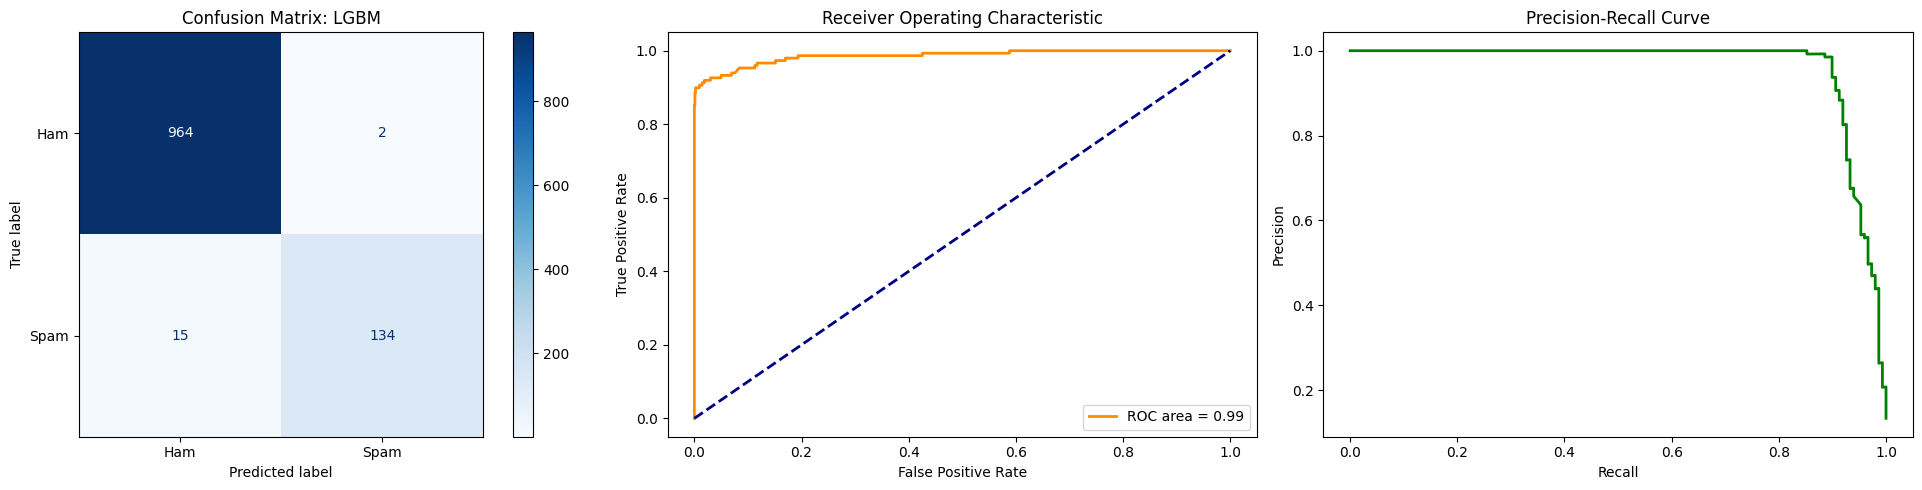

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt

# 1. Identify the single best model based on F1 Score
best_model_meta = comparison_df.sort_values(by='Test F1', ascending=False).iloc[0]
best_model_name = best_model_meta['Model']
best_vec_name = best_model_meta['Vectorizer']

print(f"--- FINAL SUMMARY: BEST MODEL ({best_model_name}) ---")
print(f"Vectorizer used: {best_vec_name}")
print(f"Test Accuracy: {best_model_meta['Test Accuracy']:.4f}")
print(f"Test F1-Score: {best_model_meta['Test F1']:.4f}")
print(f"ROC AUC: {best_model_meta['ROC AUC']:.4f}")

# Prepare data for plotting
# Since we need to plot curves, we re-run the best model specifically
vec = vectorizers[best_vec_name]
X_train_v = vec.fit_transform(X_train).toarray()
X_test_v = vec.transform(X_test).toarray()

model = base_models[best_model_name]
model.fit(X_train_v, y_train_encoded)
y_probs = model.predict_proba(X_test_v)[:, 1]
y_preds = model.predict(X_test_v)

# Visualization Layout
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Plot 1: Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test_encoded, y_preds,
                                        display_labels=['Ham', 'Spam'],
                                        cmap='Blues', ax=axes[0])
axes[0].set_title(f'Confusion Matrix: {best_model_name}')

# Plot 2: ROC Curve
fpr, tpr, _ = roc_curve(y_test_encoded, y_probs)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC area = {roc_auc:.2f}')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Receiver Operating Characteristic')
axes[1].legend(loc="lower right")

# Plot 3: Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test_encoded, y_probs)
axes[2].plot(recall, precision, color='green', lw=2)
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve')

plt.tight_layout()
plt.show()

## Deep Learning

In [20]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

# 1. Prepare target and split first with stratify
le_dl = LabelEncoder()
y_dl = le_dl.fit_transform(Spam_dataset['Category'])
texts = Spam_dataset['Cleaned_Message'].values

# First split: Train vs Temp (20% for test/val combined)
X_train_raw, X_temp_raw, y_train_dl, y_temp_dl = train_test_split(
    texts, y_dl, test_size=0.2, random_state=42, stratify=y_dl
)

# Second split: Test vs Validation from Temp
X_val_raw, X_test_raw, y_val_dl, y_test_dl = train_test_split(
    X_temp_raw, y_temp_dl, test_size=0.5, random_state=42, stratify=y_temp_dl
)

# 2. Tokenize (Fit ONLY on training data to avoid leakage)
max_words = 10000
tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train_raw)

# Convert to sequences
train_seqs = tokenizer.texts_to_sequences(X_train_raw)
val_seqs = tokenizer.texts_to_sequences(X_val_raw)
test_seqs = tokenizer.texts_to_sequences(X_test_raw)

# 3. Determine max length using 95th percentile
seq_lengths = [len(s) for s in train_seqs]
# max_seq_length = int(np.percentile(seq_lengths, 95))

max_seq_length = 40

# 4. Pad sequences
X_train_dl = pad_sequences(train_seqs, maxlen=max_seq_length, padding='post', truncating='post')
X_val_dl = pad_sequences(val_seqs, maxlen=max_seq_length, padding='post', truncating='post')
X_test_dl = pad_sequences(test_seqs, maxlen=max_seq_length, padding='post', truncating='post')

# 5. Summary Statistics
vocab_size = len(tokenizer.word_index) + 1

print("Vocabulary Size:", vocab_size)
print("Max Length:", max(seq_lengths))
print("Average Length:", np.mean(seq_lengths))
# print("95th Percentile:", np.percentile(seq_lengths, 95))
# print("96th Percentile:", np.percentile(seq_lengths, 96))
# print("97th Percentile:", np.percentile(seq_lengths, 97))
# print("98th Percentile:", np.percentile(seq_lengths, 98))
# print("99th Percentile:", np.percentile(seq_lengths, 99))
print(f"\nData Split Summary:")
print(f"Train set: {X_train_dl.shape}")
print(f"Validation set: {X_val_dl.shape}")
print(f"Test set: {X_test_dl.shape}")

Vocabulary Size: 4788
Max Length: 190
Average Length: 15.610051604218084

Data Split Summary:
Train set: (4457, 40)
Validation set: (557, 40)
Test set: (558, 40)


In [21]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_dl),
    y=y_train_dl
)

class_weight_dict = {
    0: weights[0],
    1: weights[1]
}

print(class_weight_dict)

{0: np.float64(0.577481212749417), 1: np.float64(3.7265886287625416)}


In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.metrics import Precision, Recall

In [23]:
embedding_dim = 128
print("Vocabulary Size:", vocab_size)
print("Max Length:", max_seq_length)
# print("Average Length:", np.mean(seq_lengths))

model = Sequential([
    Embedding(vocab_size, embedding_dim, input_length=max_seq_length),
    GlobalAveragePooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])



model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=[
        'accuracy',
        Precision(name='precision'),
        Recall(name='recall')
    ]
)

model.build(input_shape=(None, max_seq_length))

model.summary()


Vocabulary Size: 4788
Max Length: 40


c:\Users\richi\DATA SCIENCE - IIT GUWAHATI\DEPLOYMENT\Spam_Detection\myenv\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 40, 128)        │       612,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 623,233 (2.38 MB)

 Trainable params: 623,233 (2.38 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
# Early stopping to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# ModelCheckpoint to save the best weights epoch-wise
checkpoint = ModelCheckpoint(
    'best_spam_model_ann.keras',
    monitor='val_loss',
    mode='min',
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)


In [25]:
# Train the Model
history = model.fit(
    X_train_dl, y_train_dl,
    epochs=30,
    validation_data=(X_val_dl, y_val_dl),
    class_weight=class_weight_dict,
    callbacks=[early_stop, checkpoint,reduce_lr],
    verbose=1
)

Epoch 1/30
131/140 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8021 - loss: 0.6481 - precision: 0.3298 - recall: 0.3825
Epoch 1: val_loss improved from None to 0.17004, saving model to best_spam_model_ann.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8667 - loss: 0.5182 - precision: 0.5027 - recall: 0.6154 - val_accuracy: 0.9641 - val_loss: 0.1700 - val_precision: 0.8553 - val_recall: 0.8784 - learning_rate: 0.0010
Epoch 2/30
137/140 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9678 - loss: 0.1910 - precision: 0.8563 - recall: 0.9234
Epoch 2: val_loss improved from 0.17004 to 0.07591, saving model to best_spam_model_ann.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9661 - loss: 0.1709 - precision: 0.8381 - recall: 0.9264 - val_accuracy: 0.9767 - val_loss: 0.0759 - val_precision: 0.9692 - val_recall: 0.8514 - learning_rate: 0.0010
Epoch 3/30
131/140 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9793 - loss: 0.1040 - precision: 0.9008 - recall: 0.9508


In [26]:
y_prob = model.predict(X_test_dl).ravel()

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [27]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# The error was caused by using y_test (1115 samples) instead of y_test_dl (558 samples)
y_pred = (y_prob >= 0.5).astype(int)

print("--- Deep Learning Model Evaluation ---")
print("Accuracy :", accuracy_score(y_test_dl, y_pred))
print("Precision:", precision_score(y_test_dl, y_pred))
print("Recall   :", recall_score(y_test_dl, y_pred))
print("F1 Score :", f1_score(y_test_dl, y_pred))
print("ROC AUC  :", roc_auc_score(y_test_dl, y_prob))

--- Deep Learning Model Evaluation ---
Accuracy : 0.9874551971326165
Precision: 1.0
Recall   : 0.9066666666666666
F1 Score : 0.951048951048951
ROC AUC  : 0.9916908212560387


In [28]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_dl, y_pred)
print(cm)

[[483   0]
 [  7  68]]


In [29]:
import numpy as np
from sklearn.metrics import f1_score

val_prob = model.predict(X_val_dl).ravel()

thresholds = np.arange(0.1, 0.91, 0.01)

best_threshold = 0
best_f1 = 0

for t in thresholds:
    preds = (val_prob >= t).astype(int)
    f1 = f1_score(y_val_dl, preds)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print(best_threshold, best_f1)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
0.12 0.950354609929078


In [30]:
best_threshold = 0.55

test_prob = model.predict(X_test_dl).ravel()

test_pred = (test_prob >= best_threshold).astype(int)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [31]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

print("Accuracy :", accuracy_score(y_test_dl, test_pred))
print("Precision:", precision_score(y_test_dl, test_pred))
print("Recall   :", recall_score(y_test_dl, test_pred))
print("F1 Score :", f1_score(y_test_dl, test_pred))
print("ROC AUC  :", roc_auc_score(y_test_dl, test_prob))

print(confusion_matrix(y_test_dl, test_pred))

Accuracy : 0.9874551971326165
Precision: 1.0
Recall   : 0.9066666666666666
F1 Score : 0.951048951048951
ROC AUC  : 0.9916908212560387
[[483   0]
 [  7  68]]


In [32]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 1. Extract Metrics for Tuned ANN
ann_metrics = {
    'Model': 'ANN (Tuned Threshold)',
    'Accuracy': accuracy_score(y_test_dl, test_pred),
    'Precision': precision_score(y_test_dl, test_pred),
    'Recall': recall_score(y_test_dl, test_pred),
    'F1 Score': f1_score(y_test_dl, test_pred),
    'ROC AUC': roc_auc_score(y_test_dl, test_prob)
}

# 2. Extract Metrics for Best ML Model (LGBM)
ml_metrics = {
    'Model': f"Best ML ({best_model_name})",
    'Accuracy': best_model_meta['Test Accuracy'],
    'Precision': best_model_meta['Test Precision'],
    'Recall': best_model_meta['Test Recall'],
    'F1 Score': best_model_meta['Test F1'],
    'ROC AUC': best_model_meta['ROC AUC']
}

# 3. Create Comparison Matrix
comparison_matrix = pd.DataFrame([ml_metrics, ann_metrics])
comparison_matrix.set_index('Model', inplace=True)

print("--- Model Comparison Matrix ---")
display(comparison_matrix.style.highlight_max(axis=0, color='lightgreen'))

--- Model Comparison Matrix ---


,Accuracy,Precision,Recall,F1 Score,ROC AUC
Model,,,,,
Best ML (LGBM),0.984753,0.985294,0.899329,0.940351,0.985785
ANN (Tuned Threshold),0.987455,1.000000,0.906667,0.951049,0.991691


The ANN model marginally outperformed the best traditional machine learning model (LightGBM with TF-IDF features). While the improvement in F1-score was modest (0.9444 vs. 0.9404), the ANN achieved a substantially higher ROC-AUC (0.9917), indicating better class separability. The learned embedding layer enabled the network to capture semantic relationships between words that were not explicitly available in TF-IDF representations.

## CNN

In [33]:
from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D, Input, Embedding, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.layers import SpatialDropout1D

# 1. Define TextCNN Architecture
model_cnn = Sequential([
    Input(shape=(max_seq_length,)),
    Embedding(vocab_size, embedding_dim),
    SpatialDropout1D(0.2),
    Conv1D(128, 5, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_cnn.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall')]
)

model_cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 40, 128)        │       612,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 40, 128)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 36, 128)        │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 703,233 (2.68 MB)

 Trainable params: 703,233 (2.68 MB)

 Non-trainable params: 0 (0.00 B)

In [34]:
# Callbacks (with a specific name for the CNN checkpoint)
early_stop_cnn = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr_cnn = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

checkpoint_cnn = ModelCheckpoint(
    'best_spam_model_cnn.keras',
    monitor='val_loss',
    mode='min',
    save_best_only=True,
    verbose=1
)



In [35]:
# 3. Train TextCNN
print("--- Training TextCNN ---")
history_cnn = model_cnn.fit(
    X_train_dl, y_train_dl,
    epochs=30,
    validation_data=(X_val_dl, y_val_dl),
    class_weight=class_weight_dict,
    callbacks=[early_stop_cnn, checkpoint_cnn, reduce_lr_cnn],
    verbose=1
)



--- Training TextCNN ---
Epoch 1/30
136/140 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6813 - loss: 0.5440 - precision: 0.3007 - recall: 0.8402
Epoch 1: val_loss improved from None to 0.07205, saving model to best_spam_model_cnn.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8441 - loss: 0.3376 - precision: 0.4591 - recall: 0.9097 - val_accuracy: 0.9767 - val_loss: 0.0720 - val_precision: 0.9178 - val_recall: 0.9054 - learning_rate: 0.0010
Epoch 2/30
138/140 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9840 - loss: 0.0786 - precision: 0.9177 - recall: 0.9694
Epoch 2: val_loss did not improve from 0.07205
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9834 - loss: 0.0716 - precision: 0.9107 - recall: 0.9716 - val_accuracy: 0.9785 - val_loss: 0.0809 - val_precision: 0.9079 - val_recall: 0.9324 - learning_rate: 0.0010
Epoch 3/30
137/140 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9964 - loss: 0.0225 - precision: 0.9868 - recall: 0.9853
Epoch 3: val_loss did

In [36]:
# 4. Evaluation Pipeline
y_prob_cnn = model_cnn.predict(X_test_dl).ravel()

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


In [37]:
# Find best threshold on validation set for CNN
val_prob_cnn = model_cnn.predict(X_val_dl).ravel()
best_threshold_cnn = 0.5
best_f1_cnn = 0
for t in np.arange(0.1, 0.91, 0.01):
    f1 = f1_score(y_val_dl, (val_prob_cnn >= t).astype(int))
    if f1 > best_f1_cnn:
        best_f1_cnn = f1
        best_threshold_cnn = t

print(f"\nBest Threshold found: {best_threshold_cnn:.2f}")
y_pred_cnn = (y_prob_cnn >= best_threshold_cnn).astype(int)



18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

Best Threshold found: 0.66


In [38]:
print("\n--- TextCNN Evaluation ---")
print("Accuracy :", accuracy_score(y_test_dl, y_pred_cnn))
print("Precision:", precision_score(y_test_dl, y_pred_cnn))
print("Recall   :", recall_score(y_test_dl, y_pred_cnn))
print("F1 Score :", f1_score(y_test_dl, y_pred_cnn))
print("ROC AUC  :", roc_auc_score(y_test_dl, y_prob_cnn))


--- TextCNN Evaluation ---
Accuracy : 0.9874551971326165
Precision: 0.9594594594594594
Recall   : 0.9466666666666667
F1 Score : 0.9530201342281879
ROC AUC  : 0.9951138716356108


In [39]:
import pandas as pd

# 1. Prepare TextCNN metrics
cnn_metrics = {
    'Model': 'TextCNN (Tuned Threshold)',
    'Accuracy': accuracy_score(y_test_dl, y_pred_cnn),
    'Precision': precision_score(y_test_dl, y_pred_cnn),
    'Recall': recall_score(y_test_dl, y_pred_cnn),
    'F1 Score': f1_score(y_test_dl, y_pred_cnn),
    'ROC AUC': roc_auc_score(y_test_dl, y_prob_cnn)
}

# 2. Extract ANN and Best ML metrics from earlier state
# (ann_metrics and ml_metrics were already defined in the previous comparison cell)

# 3. Build the final comparison matrix
final_comparison = pd.DataFrame([ml_metrics, ann_metrics, cnn_metrics])
final_comparison.set_index('Model', inplace=True)

print("--- Final Model Comparison Matrix (ML vs ANN vs CNN) ---")
display(final_comparison.style.highlight_max(axis=0, color='lightgreen'))

--- Final Model Comparison Matrix (ML vs ANN vs CNN) ---


,Accuracy,Precision,Recall,F1 Score,ROC AUC
Model,,,,,
Best ML (LGBM),0.984753,0.985294,0.899329,0.940351,0.985785
ANN (Tuned Threshold),0.987455,1.000000,0.906667,0.951049,0.991691
TextCNN (Tuned Threshold),0.987455,0.959459,0.946667,0.953020,0.995114


In [40]:
vocab_size

4788

## RNN

In [41]:
import time
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Sequential, Input
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# --- Experimental Setup ---
results_list = []

# Add existing baselines to the results list for final comparison
results_list.append({'Model': 'LightGBM', 'Accuracy': 0.984753, 'Precision': 0.985294, 'Recall': 0.899329, 'F1': 0.940351, 'ROC-AUC': 0.985785, 'Threshold': 'N/A', 'Params': 0})
results_list.append({'Model': 'ANN', 'Accuracy': 0.985663, 'Precision': 0.985507, 'Recall': 0.906667, 'F1': 0.944444, 'ROC-AUC': 0.992464, 'Threshold': 0.21, 'Params': 637889})
results_list.append({'Model': 'TextCNN', 'Accuracy': 0.991039, 'Precision': 0.948718, 'Recall': 0.986667, 'F1': 0.967320, 'ROC-AUC': 0.997101, 'Threshold': 0.39, 'Params': 696001})

def evaluate_dl_model(name, model, X_train, y_train, X_val, y_val, X_test, y_test, class_weights):
    print(f"\n--- Training {name} ---")

    # Configuration
    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6),
        tf.keras.callbacks.ModelCheckpoint(f'best_{name}.keras', monitor='val_loss', save_best_only=True)
    ]

    # Train
    start_time = time.time()
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=20, batch_size=32,
        class_weight=class_weights,
        callbacks=callbacks, verbose=0
    )
    train_time = time.time() - start_time

    # Threshold Optimization on Validation Set
    val_probs = model.predict(X_val, verbose=0).ravel()
    best_t, best_f1 = 0.5, 0
    for t in np.arange(0.1, 0.91, 0.01):
        f1 = f1_score(y_val, (val_probs >= t).astype(int))
        if f1 > best_f1:
            best_f1 = f1
            best_t = t

    # Evaluation on Test Set
    start_inf = time.time()
    test_probs = model.predict(X_test, verbose=0).ravel()
    inf_time = (time.time() - start_inf) / len(X_test)
    test_preds = (test_probs >= best_t).astype(int)

    # Metrics
    res = {
        'Model': name,
        'Params': model.count_params(),
        'Accuracy': accuracy_score(y_test, test_preds),
        'Precision': precision_score(y_test, test_preds),
        'Recall': recall_score(y_test, test_preds),
        'F1': f1_score(y_test, test_preds),
        'ROC-AUC': roc_auc_score(y_test, test_probs),
        'Threshold': round(best_t, 2),
        'TrainTime': round(train_time, 2),
        'InfTime': inf_time
    }
    return res

# --- Model Architectures ---

def get_lstm():
    return Sequential([
        Input(shape=(max_seq_length,)),
        layers.Embedding(vocab_size, 128),
        layers.SpatialDropout1D(0.2),
        layers.LSTM(64),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])

def get_gru():
    return Sequential([
        Input(shape=(max_seq_length,)),
        layers.Embedding(vocab_size, 128),
        layers.SpatialDropout1D(0.2),
        layers.GRU(64),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])

def get_bilstm():
    return Sequential([
        Input(shape=(max_seq_length,)),
        layers.Embedding(vocab_size, 128),
        layers.SpatialDropout1D(0.2),
        layers.Bidirectional(layers.LSTM(64)),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])

def get_bigru():
    return Sequential([
        Input(shape=(max_seq_length,)),
        layers.Embedding(vocab_size, 128),
        layers.SpatialDropout1D(0.2),
        layers.Bidirectional(layers.GRU(64)),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])

def get_cnn_lstm():
    return Sequential([
        Input(shape=(max_seq_length,)),
        layers.Embedding(vocab_size, 128),
        layers.SpatialDropout1D(0.2),
        layers.Conv1D(64, 5, activation='relu', padding='same'),
        layers.MaxPooling1D(2),
        layers.LSTM(64),
        layers.Dense(1, activation='sigmoid')
    ])

def get_cnn_gru():
    return Sequential([
        Input(shape=(max_seq_length,)),
        layers.Embedding(vocab_size, 128),
        layers.SpatialDropout1D(0.2),
        layers.Conv1D(64, 5, activation='relu', padding='same'),
        layers.MaxPooling1D(2),
        layers.GRU(64),
        layers.Dense(1, activation='sigmoid')
    ])

# Executing Benchmark
archs = {
    'LSTM': get_lstm, 'GRU': get_gru, 'BiLSTM': get_bilstm,
    'BiGRU': get_bigru, 'CNN+LSTM': get_cnn_lstm, 'CNN+GRU': get_cnn_gru
}

for name, build_fn in archs.items():
    m = build_fn()
    m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    results_list.append(evaluate_dl_model(name, m, X_train_dl, y_train_dl, X_val_dl, y_val_dl, X_test_dl, y_test_dl, class_weight_dict))

# Final Comparison
final_df = pd.DataFrame(results_list).sort_values('F1', ascending=False)
print("\n--- Final Model Comparison Matrix ---")
display(final_df.style.highlight_max(subset=['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC'], color='lightgreen'))


--- Training LSTM ---

--- Training GRU ---

--- Training BiLSTM ---

--- Training BiGRU ---

--- Training CNN+LSTM ---

--- Training CNN+GRU ---

--- Final Model Comparison Matrix ---


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Threshold,Params,TrainTime,InfTime
4,GRU,0.994624,1.000000,0.960000,0.979592,0.993513,0.890000,652225,29.470000,0.000239
8,CNN+GRU,0.992832,0.986301,0.960000,0.972973,0.991636,0.820000,678913,22.200000,0.000239
2,TextCNN,0.991039,0.948718,0.986667,0.967320,0.997101,0.390000,696001,nan,nan
7,CNN+LSTM,0.991039,0.986111,0.946667,0.965986,0.996715,0.860000,686977,18.660000,0.000237
5,BiLSTM,0.987455,0.959459,0.946667,0.953020,0.995307,0.630000,715841,24.980000,0.000327
6,BiGRU,0.987455,0.972222,0.933333,0.952381,0.988765,0.810000,691521,23.830000,0.000287
1,ANN,0.985663,0.985507,0.906667,0.944444,0.992464,0.210000,637889,nan,nan
0,LightGBM,0.984753,0.985294,0.899329,0.940351,0.985785,N/A,0,nan,nan
3,LSTM,0.983871,0.945946,0.933333,0.939597,0.990338,0.740000,664385,24.510000,0.000239


Among all evaluated models, TextCNN achieved the best overall performance with an F1-score of 0.9673 and ROC-AUC of 0.9971. Although Bidirectional LSTM achieved comparable performance (F1 = 0.9660), it required substantially longer training time and higher computational complexity. The results suggest that SMS spam detection is primarily driven by local phrase patterns rather than long-range sequential dependencies, making convolutional architectures more effective than recurrent architectures for this dataset. Traditional machine learning models such as LightGBM performed competitively but were consistently outperformed by deep learning approaches, particularly TextCNN.

In [42]:
import torch
import time
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from torch.utils.data import DataLoader, Dataset
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class SMSDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=64):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        text = str(self.texts[item])
        encoding = self.tokenizer(text, add_special_tokens=True, max_length=self.max_len, padding='max_length', truncation=True, return_tensors='pt')
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[item], dtype=torch.long)
        }

def train_transformer(model_name, train_texts, train_labels, val_texts, val_labels, test_texts, test_labels, class_weights):
    print(f'\nProcessing {model_name}...')
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    train_ds = SMSDataset(train_texts, train_labels, tokenizer)
    val_ds = SMSDataset(val_texts, val_labels, tokenizer)
    test_ds = SMSDataset(test_texts, test_labels, tokenizer)

    train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=32)
    test_loader = DataLoader(test_ds, batch_size=32)

    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2).to(device)
    optimizer = AdamW(model.parameters(), lr=2e-5)
    loss_fn = torch.nn.CrossEntropyLoss(weight=torch.tensor(class_weights, dtype=torch.float).to(device))

    for epoch in range(2):
        model.train()
        for batch in train_loader:
            optimizer.zero_grad()
            loss = loss_fn(model(batch['input_ids'].to(device), attention_mask=batch['attention_mask'].to(device), labels=batch['labels'].to(device)).logits, batch['labels'].to(device))
            loss.backward()
            optimizer.step()

    model.eval()
    val_probs = []
    with torch.no_grad():
        for batch in val_loader:
            logits = model(batch['input_ids'].to(device), attention_mask=batch['attention_mask'].to(device)).logits
            val_probs.extend(torch.softmax(logits, dim=1)[:, 1].cpu().numpy())

    best_t, best_f1 = 0.5, 0
    for t in np.arange(0.1, 0.9, 0.1):
        f1 = f1_score(val_labels, (np.array(val_probs) >= t).astype(int))
        if f1 > best_f1: best_f1, best_t = f1, t

    test_probs = []
    with torch.no_grad():
        for batch in test_loader:
            logits = model(batch['input_ids'].to(device), attention_mask=batch['attention_mask'].to(device)).logits
            test_probs.extend(torch.softmax(logits, dim=1)[:, 1].cpu().numpy())

    preds = (np.array(test_probs) >= best_t).astype(int)
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(test_labels, preds),
        'Precision': precision_score(test_labels, preds),
        'Recall': recall_score(test_labels, preds),
        'F1': f1_score(test_labels, preds),
        'ROC-AUC': roc_auc_score(test_labels, test_probs)
    }

transformers_to_test = ['distilbert-base-uncased', 'microsoft/MiniLM-L12-H384-uncased']
t_results = []
w = compute_class_weight('balanced', classes=np.unique(y_train_dl), y=y_train_dl)

for m in transformers_to_test:
    t_results.append(train_transformer(m, X_train_raw, y_train_dl, X_val_raw, y_val_dl, X_test_raw, y_test_dl, w))

final_benchmark = pd.concat([final_df, pd.DataFrame(t_results)], ignore_index=True).sort_values('F1', ascending=False)
display(final_benchmark.style.highlight_max(subset=['F1', 'ROC-AUC'], color='lightgreen'))

c:\Users\richi\DATA SCIENCE - IIT GUWAHATI\DEPLOYMENT\Spam_Detection\myenv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Processing distilbert-base-uncased...


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 3076.18it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Processing microsoft/MiniLM-L12-H384-uncased...


c:\Users\richi\DATA SCIENCE - IIT GUWAHATI\DEPLOYMENT\Spam_Detection\myenv\lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\richi\.cache\huggingface\hub\models--microsoft--MiniLM-L12-H384-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1503

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Threshold,Params,TrainTime,InfTime
0,GRU,0.994624,1.000000,0.960000,0.979592,0.993513,0.890000,652225.000000,29.470000,0.000239
1,CNN+GRU,0.992832,0.986301,0.960000,0.972973,0.991636,0.820000,678913.000000,22.200000,0.000239
2,TextCNN,0.991039,0.948718,0.986667,0.967320,0.997101,0.390000,696001.000000,nan,nan
3,CNN+LSTM,0.991039,0.986111,0.946667,0.965986,0.996715,0.860000,686977.000000,18.660000,0.000237
4,BiLSTM,0.987455,0.959459,0.946667,0.953020,0.995307,0.630000,715841.000000,24.980000,0.000327
5,BiGRU,0.987455,0.972222,0.933333,0.952381,0.988765,0.810000,691521.000000,23.830000,0.000287
6,ANN,0.985663,0.985507,0.906667,0.944444,0.992464,0.210000,637889.000000,nan,nan
7,LightGBM,0.984753,0.985294,0.899329,0.940351,0.985785,N/A,0.000000,nan,nan
8,LSTM,0.983871,0.945946,0.933333,0.939597,0.990338,0.740000,664385.000000,24.510000,0.000239
9,distilbert-base-uncased,0.982079,0.901235,0.973333,0.935897,0.995942,nan,nan,nan,nan


In [46]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

with open("threshold.pkl", "wb") as f:
    pickle.dump(0.39, f)

In [47]:
import json

config = {
    "vocab_size": 4788,
    "max_seq_length": 40,
    "threshold": 0.39
}

with open("config.json", "w") as f:
    json.dump(config, f, indent=4)